In [2]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from pyparsing import nums

In [7]:
df = pd.read_json('names_table.jsonl', orient='records', lines=True)['text']
df = df[~df.str.contains('.', regex=False)]
df = df.apply(lambda x: x.lower())
df = df.apply(lambda x: x.replace('p','р'))
df = df.apply(lambda x: x.replace('h','н'))
chars = sorted(list(set(''.join(df))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {b:a for a,b in stoi.items()}
N = torch.zeros([len(stoi),len(stoi)], dtype=torch.int32)

In [15]:
itos

{1: '-',
 2: 'а',
 3: 'б',
 4: 'в',
 5: 'г',
 6: 'д',
 7: 'е',
 8: 'ж',
 9: 'з',
 10: 'и',
 11: 'й',
 12: 'к',
 13: 'л',
 14: 'м',
 15: 'н',
 16: 'о',
 17: 'п',
 18: 'р',
 19: 'с',
 20: 'т',
 21: 'у',
 22: 'ф',
 23: 'х',
 24: 'ц',
 25: 'ч',
 26: 'ш',
 27: 'ъ',
 28: 'ы',
 29: 'ь',
 30: 'э',
 31: 'ю',
 32: 'я',
 33: 'ё',
 0: '.'}

In [8]:
for w in df:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        i1 = stoi[ch1]
        i2 = stoi[ch2]
        N[i1, i2] += 1

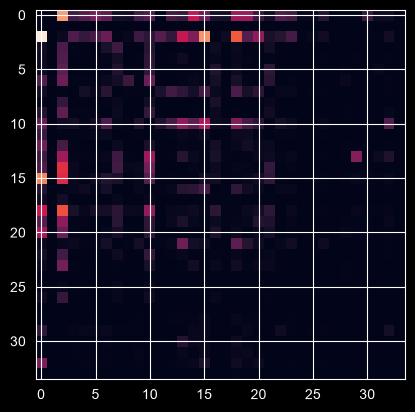

In [9]:
plt.imshow(N)

In [14]:
P = (N+1).float()
P = P / P.sum(1, keepdim=True)
g = torch.Generator().manual_seed(42)
for _ in range(10):
    out = []
    ix = 0
    while 1:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

арей.
декчвкддеветагурайлдинеруканнусанвадждитизер.
мамабдаул.
са.
киниянулм.
вамбебан.
с.
зусуджин.
аджурикизат.
раревима.


In [17]:
 xs = torch.tensor([0,5,13,13,1])

In [19]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=len(chars)).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])